# Tutorium: Einlesen, Speichern und einfaches Bearbeiten von Bildern

Zur Analyse in unseren Übungen müssen die aufgenommenen Bilder in Numpy-Arrays umgewandelt werden. Hierzu brauchen wir das Paket *imageio*, das folgendermaßen installiert wird:

* mit conda: conda install -c conda-forge imageio
* oder alternativ mit pip: pip install imageio

Dazu importieren wir natürlich Numpy und aus dem Paket *scipy* die beiden Befehle *imread* und *imwrite* (zum Lesen und Speichern von Bildern auf der Festplatte) und *pyplot* (zur Darstellung), das nach der üblichen Konvention unter dem Namen *plt* verwendet wird:

In [1]:
import numpy as np
import imageio.v3 as iio
import matplotlib.pyplot as plt

Wir arbeiten in diesem Kurs normalerweise im verlustfreien Format *PNG*. Falls Ihre Kamera Bilder in einem anderen Format abspeichert, müssen Sie in einigen Fällen die Bilder vor der Verarbeitung in Python erst in dieses Format umwandeln. Dies geht mit der üblichen Software zur Darstellung von Bildern problemlos. Achten Sie darauf, nicht das Format *JPEG* zu verwenden, da dieses verlustbehaftet und somit nicht für Messungen geeignet ist.

Das Bild, mit dem wir arbeiten werden, sieht folgendermaßen aus:

![title](stinkbug.png)

Obwohl das Bild nur Grautöne enthält, ist es in Wirklichkeit ein Farbbild im RGB-Format, d.h. es besteht aus den drei Kanälen Rot, Grün und Blau, die in diesem speziellen Fall alle drei den gleichen Wert haben, so dass ein Grauwertbild angezeigt wird.

Bitte laden Sie dieses Bild aus Moodle auf Ihren Computer und speichern es im selben Verzeichnis wie dieses Notebook.

## 1. Einlesen von Bildern

Das Einlesen von Bildern geschieht mit dem Befehl *imread*:

In [2]:
img = iio.imread('stinkbug.png')
img

array([[[104, 104, 104],
        [104, 104, 104],
        [104, 104, 104],
        ...,
        [109, 109, 109],
        [109, 109, 109],
        [109, 109, 109]],

       [[105, 105, 105],
        [105, 105, 105],
        [105, 105, 105],
        ...,
        [109, 109, 109],
        [109, 109, 109],
        [109, 109, 109]],

       [[107, 107, 107],
        [106, 106, 106],
        [106, 106, 106],
        ...,
        [110, 110, 110],
        [110, 110, 110],
        [110, 110, 110]],

       ...,

       [[112, 112, 112],
        [111, 111, 111],
        [110, 110, 110],
        ...,
        [116, 116, 116],
        [115, 115, 115],
        [115, 115, 115]],

       [[113, 113, 113],
        [113, 113, 113],
        [112, 112, 112],
        ...,
        [115, 115, 115],
        [114, 114, 114],
        [114, 114, 114]],

       [[113, 113, 113],
        [115, 115, 115],
        [115, 115, 115],
        ...,
        [114, 114, 114],
        [114, 114, 114],
        [113, 113, 113]]

Das Bild wird automatisch in ein dreidimensionales Numpy-Array vom ganzzahligen Typ *uint8* eingelesen, das direkt in Python/Numpy weiterverarbeitet werden kann. Für unsere Zwecke ist es allerdings besser, das Bild vorher in das Fließkommaformat
*float32* umzuwandeln, das sich einfacher weiterverarbeiten lässt:

In [3]:
img=img.astype('float32')
img

array([[[104., 104., 104.],
        [104., 104., 104.],
        [104., 104., 104.],
        ...,
        [109., 109., 109.],
        [109., 109., 109.],
        [109., 109., 109.]],

       [[105., 105., 105.],
        [105., 105., 105.],
        [105., 105., 105.],
        ...,
        [109., 109., 109.],
        [109., 109., 109.],
        [109., 109., 109.]],

       [[107., 107., 107.],
        [106., 106., 106.],
        [106., 106., 106.],
        ...,
        [110., 110., 110.],
        [110., 110., 110.],
        [110., 110., 110.]],

       ...,

       [[112., 112., 112.],
        [111., 111., 111.],
        [110., 110., 110.],
        ...,
        [116., 116., 116.],
        [115., 115., 115.],
        [115., 115., 115.]],

       [[113., 113., 113.],
        [113., 113., 113.],
        [112., 112., 112.],
        ...,
        [115., 115., 115.],
        [114., 114., 114.],
        [114., 114., 114.]],

       [[113., 113., 113.],
        [115., 115., 115.],
        [115., 1

## 2. Darstellung von Bildern

Die Darstellung von Bildern geschieht mit dem Befehl *plt.imshow*. Die RGB-Werte von Farbbildern müssen dazu vorher in den Wertebereich zwischen 0 und 1 skaliert werden, wie hier z.B. durch Teilen durch 255 (Maximalwert in 8-Bit-Bildern):

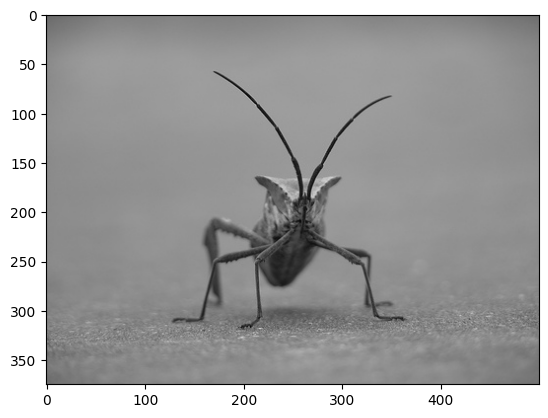

In [4]:
plt.imshow(img/255);

 oder durch Division durch den maximalen Grauwert (zur Kontrasterhöhung): 

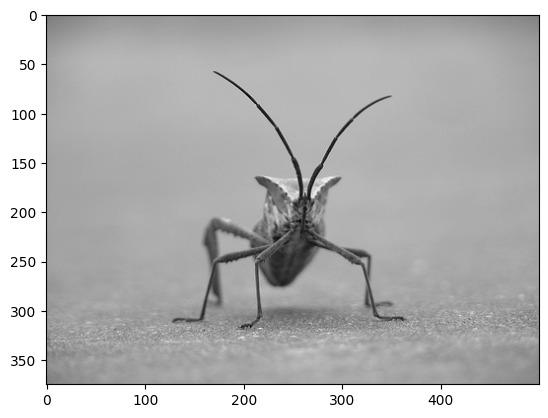

In [5]:
plt.imshow(img/img.max());

Der Strichpunkt am Ende des Befehls verhindert die zusätzliche Ausgabe von Textinformationen des Befehls *imshow*.

## 3. Einfache Bildverarbeitungsoperationen

Ausschnitte aus Bildern bekommt man über die im Numpy-Tutorium besprochenen Slicing-Operationen:

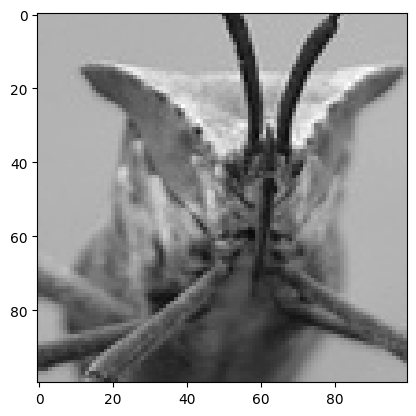

In [6]:
ausschnitt = img[150:250,200:300,:]
plt.imshow(ausschnitt/ausschnitt.max())

Die einzelnen Kanäle des Bildes erhält man ebenfalls durch Slicing, wie z.B. den Blaukanal:

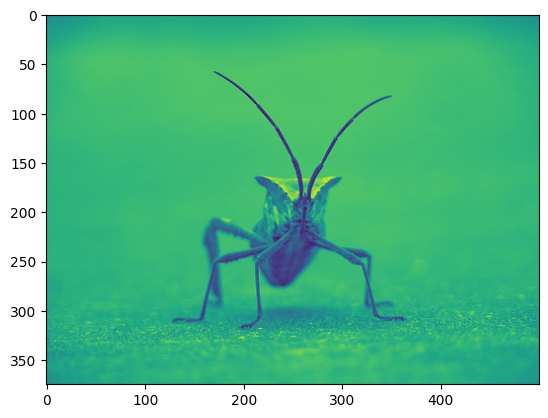

In [23]:
blau = img[:,:,2]
plt.imshow(blau);

Andere Falschfarbendarstellungen erhält man z.B. mit zusätzlichem Farbbalken

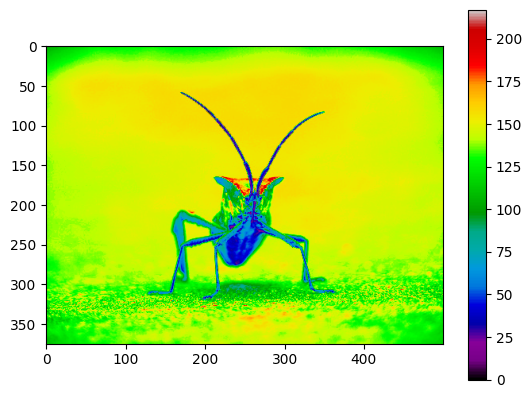

In [8]:
plt.imshow(blau, cmap="nipy_spectral");
plt.colorbar();

oder die Originalgrauwerte mit

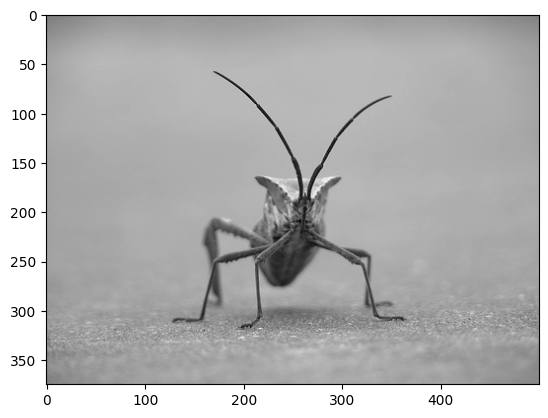

In [9]:
plt.imshow(blau, cmap="gray");

Die für das Praktikum wichtigen Werte Minimum, Maximum, Mittelwert und Standardabweichung berechnet man mit den entsprechendne Numpy-Operationen:

In [10]:
print('Minimaler Grauwert des Bildes: ', img.min())
print('Maximaler Grauwert des Bildes: ', img.max())
print('Durchschnittlicher Grauwert des Bildes: ', img.mean())
print('Standardabweichung der Grauwerte: ', img.std())

Minimaler Grauwert des Bildes:  0.0
Maximaler Grauwert des Bildes:  217.0
Durchschnittlicher Grauwert des Bildes:  140.5365
Standardabweichung der Grauwerte:  20.080706


Die Umwandlung eines Farbbildes in ein Grauwertbild geschieht entweder durch Mittelung über alle Kanäle (nicht sehr genau)

In [ ]:
grayval_img = (img[:,:,0] + img[:,:,1] + img[:,:,2])/3
grayval_img

array([[104., 104., 104., ..., 109., 109., 109.],
       [105., 105., 105., ..., 109., 109., 109.],
       [107., 106., 106., ..., 110., 110., 110.],
       ...,
       [112., 111., 110., ..., 116., 115., 115.],
       [113., 113., 112., ..., 115., 114., 114.],
       [113., 115., 115., ..., 114., 114., 113.]],
      shape=(375, 500), dtype=float32)

oder durch gewichtete Mittelung nach der Helligkeit der einzelnen Kanäle (besser):

In [ ]:
grayval_img = 0.299*img[:,:,0] + 0.587*img[:,:,1] + 0.114*img[:,:,2]
grayval_img

array([[104.     , 104.     , 104.     , ..., 109.00001, 109.00001,
        109.00001],
       [105.     , 105.     , 105.     , ..., 109.00001, 109.00001,
        109.00001],
       [107.     , 106.     , 106.     , ..., 110.     , 110.     ,
        110.     ],
       ...,
       [112.     , 110.99999, 110.     , ..., 116.     , 115.     ,
        115.     ],
       [113.     , 113.     , 112.     , ..., 115.     , 114.     ,
        114.     ],
       [113.     , 115.     , 115.     , ..., 114.     , 114.     ,
        113.     ]], shape=(375, 500), dtype=float32)

## 4. Speichern von Bildern

Die Bilder werden mit dem Befehl *imwrite* gespeichert. Allerdings unterstützen die meisten Bildformate keine Float-Bilder, daher muss man vorher das Bild in 8-Bit-Werte umwandeln, was natürlich zu einem Informationsverlust führt.

In [13]:
iio.imwrite('ausschnitt.png', ausschnitt.astype('uint8'))
a=iio.imread('ausschnitt.png')
a.max()

np.uint8(216)

Vergleich mit dem ursprünglichen Maximum:

In [ ]:
ausschnitt.max()

np.float32(216.0)